# 01 · Foundations: from a wavefunction to a quantum dot
### A first encounter with quantum mechanics for reading Pietryga et al., Section 2

**No prior QM or Python required.** This is the preparation for §2.1, not a replacement for a full QM course.
Aim for two or three sittings of about 35–50 minutes; take longer wherever you need it.

**The question to carry:** Why can changing the size of a semiconductor crystal change the energy needed to excite it?

1. Save your own working copy with **File → Save a copy in Drive**.
2. Choose **Runtime → Run all**. No GPU, data upload, or account credentials are needed by the code.
3. Read one section at a time. Predict first, then use the controls.
4. Type your reasoning in the **My reasoning** text cells. Double-click a text cell to edit.
5. Use the checkpoints to find gaps, not to collect a score.

In Colab, each experiment has visible sliders or menus above its output. Run the cell once; later control changes rerun it automatically. If a plot does not refresh, press its ▶ button.
The saved plots are previews. Save your reasoning in text cells; GitHub preview does not run the controls.

**Success looks like:** explaining probability, confinement, effective mass, holes, and photon energy in your own words.
All plots and numbers here are model calculations, not measurements.

**Updated edition:** Section 3 now derives the box wavefunction step by step. Controls use native Colab forms. If you saved an earlier Drive copy, reopen this GitHub-linked edition and make a new copy; existing Drive copies do not automatically receive these edits.

In [1]:
# @title Start the lesson (run once; a CPU runtime is enough)
import importlib.util
import subprocess
import sys
needed = {'numpy': 'numpy>=1.24', 'scipy': 'scipy>=1.10',
          'matplotlib': 'matplotlib>=3.7', 'ipywidgets': 'ipywidgets>=8.0'}
missing = [spec for module, spec in needed.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
try:
    from google.colab import output
    IN_COLAB=True
except ImportError:
    IN_COLAB=False
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from scipy.special import spherical_jn
from scipy.optimize import brentq
from scipy.integrate import quad
from functools import lru_cache
import ipywidgets as W
from IPython.display import display, HTML, clear_output
get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 12})
BLUE, ORANGE, GREEN, GRAY = '#215f9a', '#b95524', '#267969', '#626977'
K = constants.hbar**2/(2*constants.m_e*constants.e)*1e18  # eV nm^2
C = constants.e/(4*np.pi*constants.epsilon_0)*1e9        # eV nm
HC = constants.h*constants.c/constants.e*1e9           # eV nm
A0 = constants.physical_constants['Bohr radius'][0]*1e9
LABS, QUIZZES = {}, {}

def slider(label, value, minimum, maximum, step):
    return W.FloatSlider(description=label, value=value, min=minimum, max=maximum,
        step=step, continuous_update=False, readout_format='.2f',
        style={'description_width': '130px'}, layout=W.Layout(width='440px', max_width='100%'))

def lab(key, fn, controls, form_values=None):
    """Colab uses native form fields; Jupyter uses visible, live widgets."""
    if form_values is not None:
        for name,value in form_values.items():
            controls[name].value=value
    values={k:w.value for k,w in controls.items()}
    if IN_COLAB:
        LABS[key]=(fn,controls,None)
        display(HTML('<p><b>Colab controls are above the plot.</b> Run this cell once; subsequent control changes rerun it automatically. If needed, press ▶ again.</p>'))
        fn(**values)
    else:
        live=W.interactive_output(fn,controls)
        LABS[key]=(fn,controls,live)
        display(W.VBox([*controls.values(),live]))
        display(HTML('<p><b>Saved preview.</b> In Colab, use the form controls at the top of this cell and run it. In Jupyter, use the live controls above.</p>'))
        fn(**values)

def quiz(key, prompt, choices, correct, explanations, form_answer='Choose an answer'):
    if IN_COLAB:
        display(HTML('<p><b>'+prompt+'</b></p>'))
        if form_answer not in choices:
            display(HTML('<p>Choose your answer in the form above. Run once to enable automatic feedback.</p>'))
        else:
            i=choices.index(form_answer)
            prefix='Correct. ' if i==correct else 'Try again. '
            display(HTML('<p><b>'+prefix+'</b>'+explanations[i]+'</p>'))
        return
    select=W.RadioButtons(options=[('Choose an answer',-1)]+[(s,i) for i,s in enumerate(choices)],
                          value=-1,layout=W.Layout(width='100%'))
    button=W.Button(description='Check reasoning',button_style='info')
    result=W.HTML()
    def check(_):
        i=select.value
        if i<0: result.value='<p>Choose an answer first.</p>'
        else:
            prefix='Correct. ' if i==correct else 'Try again. '
            result.value='<p><b>'+prefix+'</b>'+explanations[i]+'</p>'
    button.on_click(check)
    QUIZZES[key]=(select,button,result,check,correct,explanations)
    display(W.VBox([W.HTML('<b>'+prompt+'</b>'),select,button,result]))

print('Ready. Colab: controls are built into each experiment. Run a cell once, then change its controls; press ▶ if it does not refresh.')

Ready. Colab: controls are built into each experiment. Run a cell once, then change its controls; press ▶ if it does not refresh.


## 1 · Get comfortable with the units

A nanometre is a billionth of a metre: $1\ \mathrm{nm}=10^{-9}\ \mathrm m$.
A dot with radius $R=3$ nm has diameter $D=6$ nm. These are easy to confuse; using diameter where a formula asks for radius changes a $1/R^2$ term by a factor of four.

An electronvolt is an **energy**, not a voltage:
$1\ \mathrm{eV}=1.602176634\times10^{-19}$ joules.
One meV is $0.001$ eV. Electron masses below are quoted in units of the free-electron mass $m_0$.

A photon has energy
$$E_\gamma=\frac{hc}{\lambda}\approx\frac{1240\ \mathrm{eV\,nm}}{\lambda\;(\mathrm{nm})}.$$
Here $h$ is Planck's constant, $c$ is the speed of light, and $\lambda$ is the vacuum wavelength.

**Predict:** Does increasing photon energy increase or decrease wavelength?

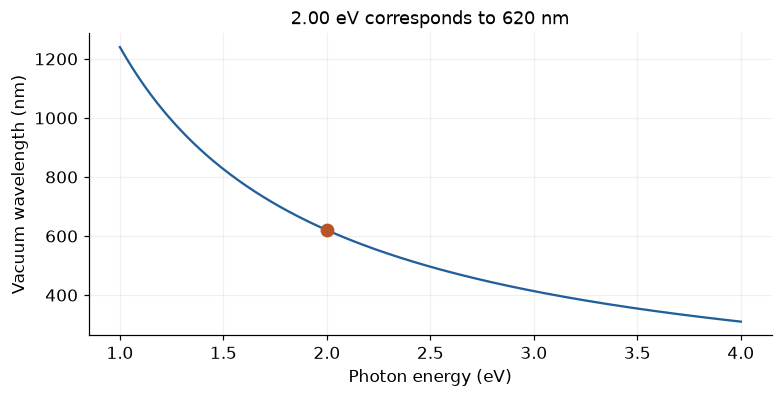

In [2]:
# @title Experiment 1 — energy and wavelength {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
photon_energy_eV = 2.0 # @param {"type": "slider", "min": 1.0, "max": 4.0, "step": 0.05}

def photon_plot(energy_eV=2.0):
    e=np.linspace(1,4,300)
    fig,ax=plt.subplots(figsize=(7,3.5),layout='constrained')
    ax.plot(e,HC/e,color=BLUE)
    ax.scatter([energy_eV],[HC/energy_eV],color=ORANGE,s=65,zorder=3)
    ax.set(xlabel='Photon energy (eV)',ylabel='Vacuum wavelength (nm)',
           title=f'{energy_eV:.2f} eV corresponds to {HC/energy_eV:.0f} nm')
    ax.grid(alpha=.18)
    plt.show()
lab('photon',photon_plot,{'energy_eV':slider('Energy (eV)',2,1,4,.05)}, form_values={'energy_eV': photon_energy_eV})

**My reasoning:** If photon energy doubles, wavelength ______ because ______.

## 2 · A wavefunction is a probability amplitude

In classical mechanics you might track a particle's position and velocity. In QM a **state** gives the information used to predict measurement outcomes. A **wavefunction**, $\psi(x)$, represents that state as a function of position.

It is not a literal orbit or a spread-out piece of negative charge. For one particle,
$$P(a\le x\le b)=\int_a^b |\psi(x)|^2\,dx.$$
Read this as: square the amplitude's magnitude, then add the resulting probability density over the interval.

- $\psi$ can be negative or complex. The probability density $|\psi|^2$ cannot be negative.
- Density is probability **per unit length** in 1D; density at a point is not the probability of an exact point.
- **Normalization** means the total probability is one.
- A **node** is a place where the wavefunction is zero.
- Repeating a measurement on many independently prepared copies produces a distribution. It does not trace one particle's path.

For a real wavefunction, $|\psi|^2=\psi^2$. Multiplying the whole wavefunction by $-1$ changes no position probabilities. Relative signs between components can matter for interference; that is a later topic.

**Predict:** Can the negative lobe of a wavefunction mean negative probability? What happens to the probability density if the whole amplitude changes sign?

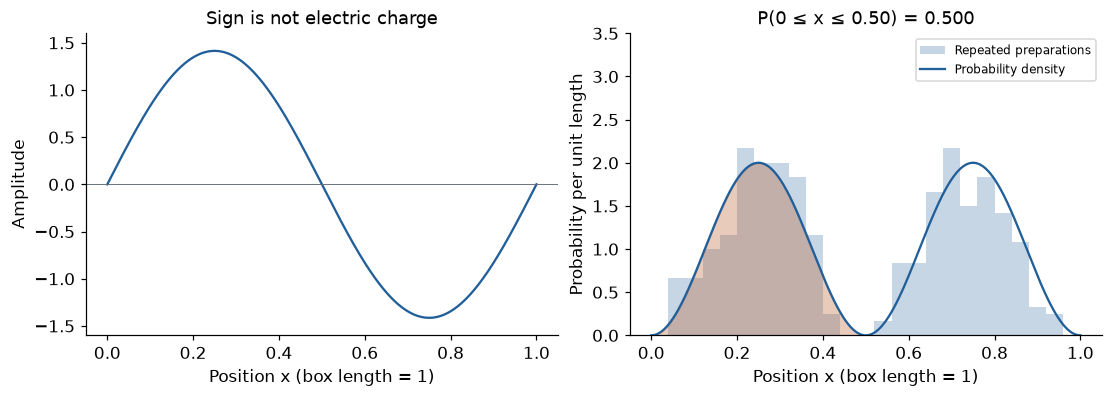

In [3]:
# @title Experiment 2 — signed amplitude, probability, and repeated measurements {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
state_n = 2 # @param {"type": "slider", "min": 1, "max": 4, "step": 1}
overall_sign = '+ψ' # @param ["+ψ", "−ψ"]
interval_end = 0.5 # @param {"type": "slider", "min": 0.05, "max": 1.0, "step": 0.05}
number_of_preparations = 300 # @param {"type": "slider", "min": 100, "max": 3000, "step": 100}

def probability_plot(n=2, sign=1, upper=.5, samples=300):
    x=np.linspace(0,1,1501)
    psi=sign*np.sqrt(2)*np.sin(n*np.pi*x)
    density=psi**2
    cdf=x-np.sin(2*n*np.pi*x)/(2*n*np.pi)
    rng=np.random.default_rng(17)
    positions=np.interp(rng.random(samples),cdf,x)
    probability=upper-np.sin(2*n*np.pi*upper)/(2*n*np.pi)
    fig,ax=plt.subplots(1,2,figsize=(10,3.5),layout='constrained')
    ax[0].plot(x,psi,color=BLUE,label='Amplitude ψ')
    ax[0].axhline(0,color=GRAY,lw=.6)
    ax[0].set(xlabel='Position x (box length = 1)',ylabel='Amplitude',
              title='Sign is not electric charge',ylim=(-1.6,1.6))
    ax[1].hist(positions,bins=np.linspace(0,1,26),density=True,alpha=.25,color=BLUE,label='Repeated preparations')
    ax[1].plot(x,density,color=BLUE,label='Probability density')
    ax[1].fill_between(x,0,density,where=x<=upper,color=ORANGE,alpha=.3)
    ax[1].set(xlabel='Position x (box length = 1)',ylabel='Probability per unit length',
              title=f'P(0 ≤ x ≤ {upper:.2f}) = {probability:.3f}',ylim=(0,3.5))
    ax[1].legend(fontsize=8)
    plt.show()
lab('probability',probability_plot,{
    'n':W.IntSlider(description='State n',value=2,min=1,max=4,continuous_update=False),
    'sign':W.Dropdown(description='Overall sign',options=[('+ψ',1),('−ψ',-1)],value=1),
    'upper':slider('Interval end',.5,.05,1,.05),
    'samples':W.IntSlider(description='Preparations',value=300,min=100,max=3000,step=100,continuous_update=False)}, form_values={'n': int(state_n), 'sign': {'+ψ': 1, '−ψ': -1}[overall_sign], 'upper': interval_end, 'samples': int(number_of_preparations)})

**Try:** Change the sign. Change the number of preparations. Select $n=2$ and the left half of the box.

**My reasoning:** The histogram changes with sample count because ______. The negative lobe means ______.

<details><summary>Reveal after explaining</summary>
Changing the overall sign leaves density unchanged. More independently prepared particles make the histogram approach the predicted density, with sampling fluctuations remaining. For n = 2 the left-half probability is 1/2. A negative amplitude is not negative probability.
</details>

## 3 · Why confinement produces particular energies
### Derive the wavefunction instead of taking it on trust

We want to understand every part of
$$\psi_n(x)=\sqrt{\frac{2}{a}}\sin\left(\frac{n\pi x}{a}\right).$$
Why a sine? Why $n\pi/a$? Why the square root? They come from **three different requirements**:

1. The Schrödinger equation determines which shapes can have one definite energy.
2. The walls select which of those shapes fit.
3. Total probability one sets the amplitude.

Work through 3A–3F in order. The energy formula comes at the end.

### 3A · Specify the physical situation

Picture a particle that can be found anywhere along a line between $x=0$ and $x=a$.
Here $x$ is a position you can vary; $a$ is the fixed box length, not an area.

We idealize its potential energy as
$$V(x)=\begin{cases}
0,&0<x<a,\\
+\infty,&x<0\ \text{or}\ x>a.
\end{cases}$$

**Potential energy** describes the energetic cost associated with position. Zero inside means no position is favoured there; it does not mean the particle's total energy is zero.
The infinite walls are the limiting idealization of barriers the particle cannot penetrate.

Consequently the wavefunction is zero outside. Taking the infinite-barrier limit of a continuous wavefunction also gives
$$\psi(0)=0,\qquad \psi(a)=0.$$
These are the **boundary conditions**. A fixed-end string is a useful picture for fitting standing-wave shapes, but an electron's wavefunction is a probability amplitude, not a vibrating string.

**Pause:** Which statement is being set to zero: the potential *inside* the box, the probability amplitude *at the walls*, or both? Are those the same physical quantity?

**My reasoning:**

### 3B · What selects the shape inside the box?

We are looking for a **state with one definite energy** $E$, also called an energy eigenstate.
Its spatial wavefunction obeys the time-independent Schrödinger equation:
$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2}+V(x)\psi=E\psi.$$

This equation is a basic rule of nonrelativistic quantum mechanics, supported by experiment. We are not deriving that rule from the string analogy; we are solving it for this particular potential.

Read the symbols slowly:

- $m$ is the particle's mass; later it becomes a carrier's effective mass.
- $\hbar=h/(2\pi)$ is the reduced Planck constant.
- $d\psi/dx$ is the **slope** of the amplitude curve.
- $d^2\psi/dx^2$ is the rate at which the slope changes: its **curvature**.
- $-(\hbar^2/2m)d^2/dx^2$ is the kinetic-energy operation.
- $V\psi$ is the potential-energy part; $E\psi$ says the state has the definite energy $E$.

Inside this box $V=0$. Move the constants to the other side:
$$\frac{d^2\psi}{dx^2}=-\frac{2mE}{\hbar^2}\psi=-k^2\psi,
\qquad k^2=\frac{2mE}{\hbar^2}.$$

**In words:** the curve's curvature must be a fixed negative multiple of its height at every interior point.
At a positive peak it bends down; at a negative trough it bends up.

Sines and cosines do exactly that:
$$\frac{d^2}{dx^2}\sin(kx)=-k^2\sin(kx),\qquad
\frac{d^2}{dx^2}\cos(kx)=-k^2\cos(kx).$$
Each differentiation supplies a factor of $k$; differentiating twice restores the shape with a minus sign.
For $E>0$, the general solution is therefore
$$\psi(x)=A\sin(kx)+B\cos(kx).$$

$A$ and $B$ are constants setting how much of each shape is present.
We can choose a real spatial wavefunction for these eigenstates; its overall phase does not affect the probability.

Why not a triangle that also touches both walls? Between its corners, its curvature is zero even where its height is nonzero, so it does not satisfy this equation for one positive energy. **Meeting the walls alone is not enough.** A more general initial state can be a superposition of the allowed energy eigenstates; we will return to that distinction.

**My reasoning:** A sine appears because its second derivative ______, not merely because it looks like a wave.

### 3C · Apply the left wall, then the right wall

At the left wall,
$$0=\psi(0)=A\sin(0)+B\cos(0)=B.$$
So the left wall eliminates the cosine term:
$$\psi(x)=A\sin(kx).$$
This choice of sine depends on putting the left wall at $x=0$. A centred coordinate system would give a mixture of sine-type and cosine-type eigenstates.

At the right wall,
$$0=\psi(a)=A\sin(ka).$$
We cannot choose $A=0$, because the entire wavefunction would vanish and its total probability would be zero.
We therefore need $\sin(ka)=0$. Sine is zero at integer multiples of $\pi$:
$$ka=n\pi,\qquad k_n=\frac{n\pi}{a},\qquad n=1,2,3,\ldots.$$

This is where the integer $n$ enters. We did not put quantization into the energy formula by hand.

The wave number $k=2\pi/\lambda$ counts spatial variation. Hence
$$\lambda_n=\frac{2a}{n}.$$
Exactly $n$ half-wavelengths fit between the walls:
$n=1$ has one arch, $n=2$ has two opposite-sign arches, and so on.

**What about zero or negative $n$?** Zero gives $\sin(0)=0$ everywhere. More carefully, at $E=0$ the equation is $\psi''=0$, so $\psi=A+Bx$; imposing both walls again gives only the zero function. Negative integers produce the same spatial states up to an overall sign. The nonnegative kinetic-energy operator rules out negative energies for this zero-interior-potential box.

**Predict before touching the control:** Will 1.5 half-wavelengths fit both walls? What must the right endpoint do when the number reaches 2?

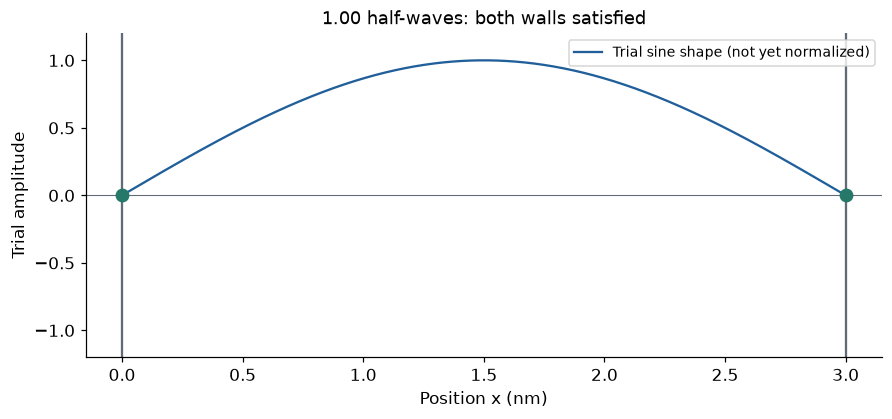

ψ(a)/A = sin(1.00π) = +0.0000.  k = 1.0472 nm⁻¹.
A noninteger trial is not an allowed energy eigenstate of this box.


In [4]:
# @title Experiment 3A — make a trial wave satisfy both walls {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
number_of_half_waves = 1.0 # @param {"type": "slider", "min": 0.5, "max": 4.5, "step": 0.05}
box_length_nm = 3.0 # @param {"type": "slider", "min": 1.0, "max": 6.0, "step": 0.25}

def wall_plot(half_waves=1.,length_nm=3.):
    x=np.linspace(0,length_nm,800)
    k=half_waves*np.pi/length_nm
    y=np.sin(k*x)
    endpoint=float(np.sin(np.pi*half_waves))
    allowed=abs(endpoint)<1e-10
    fig,ax=plt.subplots(figsize=(8,3.7),layout='constrained')
    ax.plot(x,y,color=BLUE,label='Trial sine shape (not yet normalized)')
    ax.axhline(0,color=GRAY,lw=.7)
    ax.axvline(0,color=GRAY);ax.axvline(length_nm,color=GRAY)
    ax.scatter([0,length_nm],[0,endpoint],s=65,color=GREEN if allowed else ORANGE,zorder=4)
    ax.set(xlabel='Position x (nm)',ylabel='Trial amplitude',
           ylim=(-1.2,1.2),title=f'{half_waves:.2f} half-waves: '+('both walls satisfied' if allowed else 'right wall NOT satisfied'))
    ax.legend(loc='upper right',fontsize=9)
    plt.show()
    print(f'ψ(a)/A = sin({half_waves:.2f}π) = {endpoint:+.4f}.  k = {k:.4f} nm⁻¹.')
    print('A noninteger trial is not an allowed energy eigenstate of this box.')
lab('wall',wall_plot,{
    'half_waves':slider('Half-waves',1,.5,4.5,.05),
    'length_nm':slider('Length a (nm)',3,1,6,.25)}, form_values={'half_waves': number_of_half_waves, 'length_nm': box_length_nm})

**Try:** Compare 1, 1.5, 2, and 2.5 half-waves. Then change the box length while keeping the number of half-waves fixed.

**My reasoning:** The accepted values are ______. A noninteger trial fails because ______.
When the box length doubles while the same number of arches fit, $k$ ______.

<details><summary>Reveal after trying</summary>
Positive integers fit both walls. At 1.5 and 2.5 the sine is nonzero at the right wall. Holding the same integer number of half-waves while doubling length halves k and doubles the wavelength.
</details>

### 3D · Derive the amplitude from total probability

The walls have given us $\psi_n(x)=A\sin(n\pi x/a)$, but have not determined $A$.
A particle must be found somewhere in the box, so
$$1=\int_0^a|\psi_n(x)|^2\,dx
=|A|^2\int_0^a\sin^2\left(\frac{n\pi x}{a}\right)dx.$$

Squaring makes every lobe positive. Across an integer number of half-waves, the average of sine squared is $1/2$. Thus the area is $a/2$:
$$\int_0^a\sin^2\left(\frac{n\pi x}{a}\right)dx=\frac a2.$$
If you want the calculus step, use $\sin^2 z=(1-\cos 2z)/2$:
$$\left[\frac x2-\frac{a}{4n\pi}\sin\left(\frac{2n\pi x}{a}\right)\right]_0^a
=\frac a2.$$
The sine term vanishes at both limits.

Now $1=|A|^2a/2$, so we may choose $A=\sqrt{2/a}$.
A minus sign, or a constant complex phase of magnitude one, would describe the same physical state.

We have derived the answer:
$$\boxed{\psi_n(x)=\sqrt{\frac2a}\sin\left(\frac{n\pi x}{a}\right),\quad 0<x<a.}$$
Outside, the wavefunction is zero.

**The three pieces:** sine comes from the differential equation; $n\pi/a$ from the walls; $\sqrt{2/a}$ from normalization.
If $x$ is measured in nm, $\psi$ has units nm$^{-1/2}$, and $|\psi|^2dx$ is dimensionless probability.

**Predict:** If you double the amplitude without changing the shape, does the integrated probability double or quadruple?

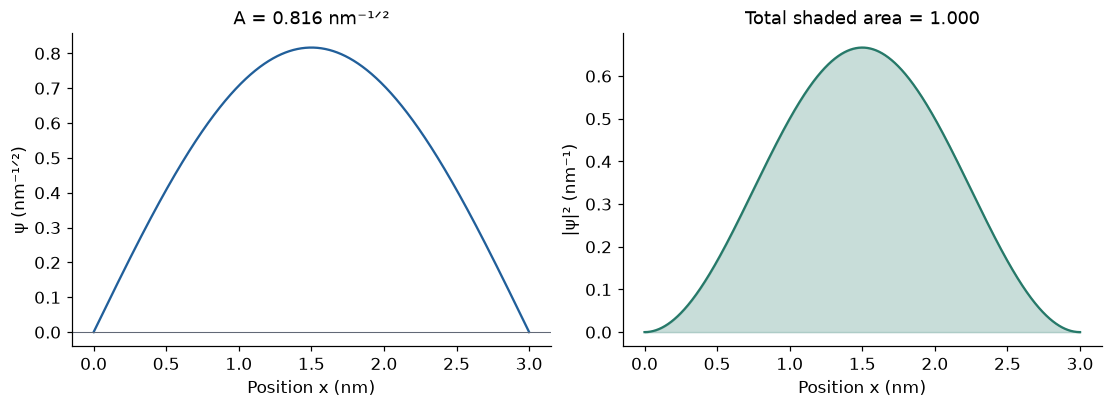

Normalized.
Only an area of 1 gives a normalized one-particle probability distribution.


In [5]:
# @title Experiment 3B — normalize the wavefunction {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
box_length_nm = 3.0 # @param {"type": "slider", "min": 1.0, "max": 6.0, "step": 0.25}
state_n = 1 # @param {"type": "slider", "min": 1, "max": 4, "step": 1}
amplitude_factor = 1.0 # @param {"type": "slider", "min": 0.25, "max": 2.0, "step": 0.25}

def normalization_plot(length_nm=3.,n=1,amplitude_factor=1.):
    x=np.linspace(0,length_nm,1200)
    amplitude=amplitude_factor*np.sqrt(2/length_nm)
    psi=amplitude*np.sin(n*np.pi*x/length_nm)
    total=amplitude_factor**2
    fig,ax=plt.subplots(1,2,figsize=(10,3.6),layout='constrained')
    ax[0].plot(x,psi,color=BLUE)
    ax[0].axhline(0,color=GRAY,lw=.7)
    ax[0].set(xlabel='Position x (nm)',ylabel='ψ (nm⁻¹ᐟ²)',
              title=f'A = {amplitude:.3f} nm⁻¹ᐟ²')
    ax[1].plot(x,psi**2,color=GREEN)
    ax[1].fill_between(x,0,psi**2,color=GREEN,alpha=.25)
    ax[1].set(xlabel='Position x (nm)',ylabel='|ψ|² (nm⁻¹)',
              title=f'Total shaded area = {total:.3f}')
    plt.show()
    print('Normalized.' if np.isclose(total,1) else 'Not normalized: adjust the amplitude factor to make the area 1.')
    print('Only an area of 1 gives a normalized one-particle probability distribution.')
lab('normalization',normalization_plot,{
    'length_nm':slider('Length a (nm)',3,1,6,.25),
    'n':W.IntSlider(description='State n',value=1,min=1,max=4,continuous_update=False),
    'amplitude_factor':slider('Amplitude factor',1,.25,2,.25)}, form_values={'length_nm': box_length_nm, 'n': int(state_n), 'amplitude_factor': amplitude_factor})

**Try:** Set the amplitude factor to 1, then 2. Restore it to 1, then change $n$ and the box length.

**My reasoning:** Doubling amplitude changes total area by a factor of ______.
At the normalized amplitude, changing $n$ leaves total area ______.

<details><summary>Reveal after calculating</summary>
Doubling amplitude quadruples the density and its integral. With the factor restored to 1, every allowed n has total area one. When the box gets longer, the prefactor gets smaller so the probability remains one over the larger interval.
</details>

### 3E · The allowed shapes determine the allowed energies

Recall the definition we introduced when solving the differential equation:
$$k^2=\frac{2mE}{\hbar^2},\qquad E=\frac{\hbar^2k^2}{2m}.$$
Insert the values the walls permit, $k_n=n\pi/a$:
$$\boxed{E_n=\frac{\hbar^2\pi^2n^2}{2ma^2}.}$$

Here **quantization** means that an energy measurement returns one of these allowed values.
A particle need not initially be in just one eigenstate; a superposition has probabilities for different allowed energy outcomes.

The ground state $n=1$ has a nonzero energy because no nonzero normalized zero-energy shape satisfies both walls.
More arches in the same length mean larger curvature and higher kinetic energy.
Squeezing the same state into a smaller length also increases curvature and energy.

**Predict:** If the box doubles in length, what happens to $E_1$? If mass doubles? Is $E_2$ twice $E_1$?

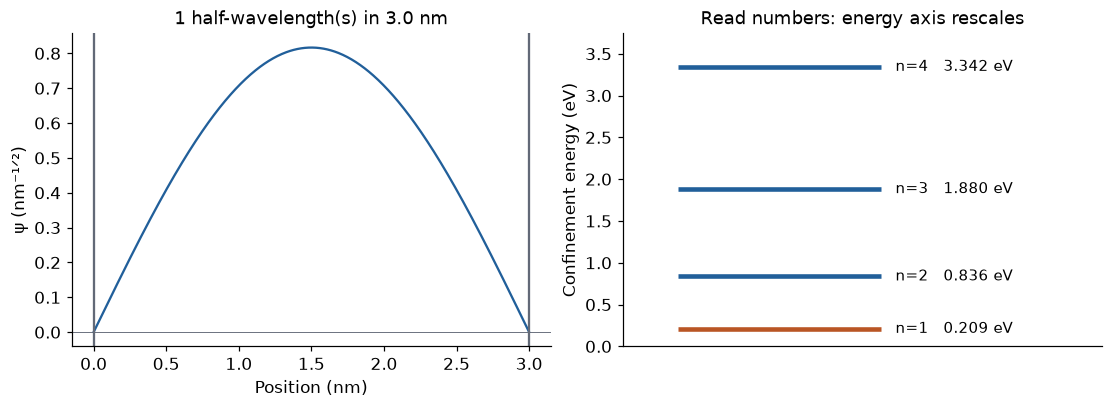

In [6]:
# @title Experiment 3 — waves that fit and the cost of confinement {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
box_length_nm = 3.0 # @param {"type": "slider", "min": 1.0, "max": 6.0, "step": 0.25}
mass_in_electron_masses = 0.2 # @param {"type": "slider", "min": 0.1, "max": 1.0, "step": 0.05}
state_n = 1 # @param {"type": "slider", "min": 1, "max": 4, "step": 1}

def box_plot(length_nm=3.,mass_ratio=.2,n=1):
    x=np.linspace(0,length_nm,700)
    levels=K*np.pi**2*np.arange(1,5)**2/(mass_ratio*length_nm**2)
    fig,ax=plt.subplots(1,2,figsize=(10,3.6),layout='constrained')
    ax[0].plot(x,np.sqrt(2/length_nm)*np.sin(n*np.pi*x/length_nm),color=BLUE)
    ax[0].axvline(0,color=GRAY);ax[0].axvline(length_nm,color=GRAY)
    ax[0].axhline(0,color=GRAY,lw=.6)
    ax[0].set(xlabel='Position (nm)',ylabel='ψ (nm⁻¹ᐟ²)',
              title=f'{n} half-wavelength(s) in {length_nm:.1f} nm')
    for i,e in enumerate(levels,1):
        ax[1].hlines(e,.15,.7,color=ORANGE if i==n else BLUE,lw=3)
        ax[1].text(.74,e,f'n={i}   {e:.3f} eV',va='center',fontsize=10)
    ax[1].set(xlim=(0,1.3),ylim=(0,levels[-1]*1.12),xticks=[],
              ylabel='Confinement energy (eV)',title='Read numbers: energy axis rescales')
    plt.show()
lab('box',box_plot,{'length_nm':slider('Length a (nm)',3,1,6,.25),
                   'mass_ratio':slider('Mass m/m₀',.2,.1,1,.05),
                   'n':W.IntSlider(description='State n',value=1,min=1,max=4,continuous_update=False)}, form_values={'length_nm': box_length_nm, 'mass_ratio': mass_in_electron_masses, 'n': int(state_n)})

**My reasoning:** Doubling length gives ______ times the energy. Doubling mass gives ______. $E_2/E_1=$ ______.

<details><summary>Reveal the ratios</summary>
At fixed state, doubling length divides energy by four. Doubling mass divides it by two. The n = 2 state has four times the ground-state energy.
</details>

### 3F · Check the solution and avoid a misleading picture

We can substitute the derived shape back into the original equation:
$$-\frac{\hbar^2}{2m}\frac{d^2\psi_n}{dx^2}
=-\frac{\hbar^2}{2m}\left[-\left(\frac{n\pi}{a}\right)^2\psi_n\right]
=E_n\psi_n.$$
The two minus signs cancel. The same wavefunction returns multiplied by its energy: this is what **eigenfunction** and **eigenvalue** mean here.

You may also know $p=\hbar k$ and kinetic energy $p^2/(2m)$. They give the same energy scale.
However, a standing wave in a box is not a particle with one definite directed momentum bouncing along a known path. Its mean momentum is zero while its mean squared momentum is positive. Strictly, releasing it from the box produces a spread of possible momenta; the box state is not a two-point free-momentum distribution.

An energy eigenstate evolves as
$$\Psi(x,t)=\psi_n(x)e^{-iE_nt/\hbar}.$$
The exponential is a **phase factor** of magnitude one; $i$ is the imaginary unit with $i^2=-1$.
You do not need complex-number calculations here: when taking $|\Psi|^2$, that factor cancels.
Its probability density is stationary, but its kinetic energy is nonzero.
Superpositions of different-energy states can have probability densities that change with time.

### Explain the equation without looking up

For each part of $\sqrt{2/a}\sin(n\pi x/a)$, explain what requirement would be violated if we removed it.
Then explain why an arbitrary curve that touches both walls need not be a state of one definite energy.

**My explanation:**

In [7]:
# @title Checkpoint — a stationary state {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
your_answer = "Choose an answer" # @param ["Choose an answer", "the particle has zero kinetic energy.", "the state can still have nonzero kinetic energy.", "the particle follows a fixed circular orbit."]

quiz('stationary','The ground-state probability density does not change with time. Therefore…',
     ['the particle has zero kinetic energy.',
      'the state can still have nonzero kinetic energy.',
      'the particle follows a fixed circular orbit.'],1,
     ['The lowest box energy is positive; a stationary density is not a classical rest state.',
      'The time-dependent phase cancels in |Ψ|², while the state still has energy E₁.',
      'A probability distribution is not a trajectory; this model specifies no circular orbit.'], form_answer=your_answer)

## 4 · A semiconductor adds a crystal underneath the wave

A solid contains many atoms and many possible electron states. Their energies form **bands**.
The **valence band** is filled in the ideal unexcited picture; the **conduction band** is empty.
The **band gap** $E_{g,0}$ is the separation between their edges. Real occupations can change with temperature or doping; we begin with the simple picture.

An excitation promotes an electron into the conduction band and leaves a missing electron in the valence band. We describe that vacancy as a **hole**: a useful positively charged excitation, not a proton and not an empty cavity.

Near a conduction-band minimum the electron energy often behaves approximately as
$$E(k)-E_{\mathrm{CB}}=\frac{\hbar^2k^2}{2m_e^*}.$$
The **effective mass** $m_e^*$ expresses how the electron responds within the crystal. It is not a new value of its vacuum rest mass. A more curved band corresponds to a smaller effective mass; a flatter band to a larger one. Hole energy measured away from the valence maximum is likewise positive and can be approximated with a positive hole mass $m_h^*$.

**Predict:** At the same wave number, which has higher excitation energy: a light carrier or a heavy carrier?

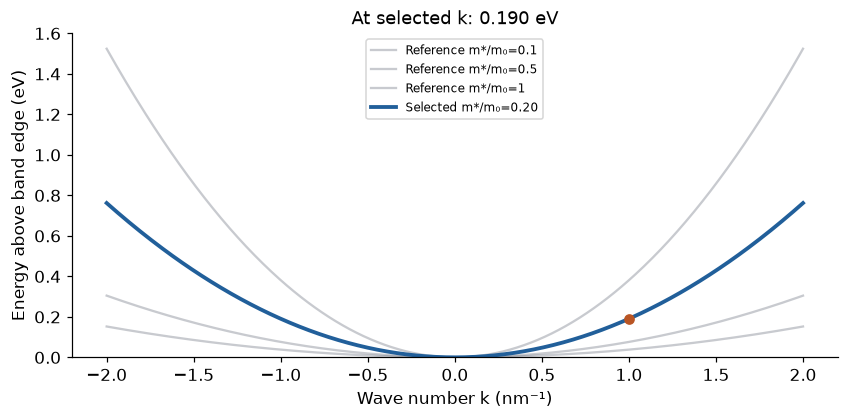

In [8]:
# @title Experiment 4 — effective mass is band curvature {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
mass_in_electron_masses = 0.2 # @param {"type": "slider", "min": 0.1, "max": 1.0, "step": 0.05}
wave_number_per_nm = 1.0 # @param {"type": "slider", "min": 0.0, "max": 2.0, "step": 0.1}

def mass_plot(mass_ratio=.2,k_selected=1.):
    k=np.linspace(-2,2,500)
    fig,ax=plt.subplots(figsize=(7.6,3.7),layout='constrained')
    for mass in [.1,.5,1.]:
        ax.plot(k,K*k*k/mass,color=GRAY,alpha=.35,label=f'Reference m*/m₀={mass:g}')
    ax.plot(k,K*k*k/mass_ratio,color=BLUE,lw=2.5,label=f'Selected m*/m₀={mass_ratio:.2f}')
    ax.scatter([k_selected],[K*k_selected**2/mass_ratio],color=ORANGE,zorder=4)
    ax.set(xlabel='Wave number k (nm⁻¹)',ylabel='Energy above band edge (eV)',
           ylim=(0,1.6),title=f'At selected k: {K*k_selected**2/mass_ratio:.3f} eV')
    ax.legend(fontsize=8)
    plt.show()
lab('mass',mass_plot,{'mass_ratio':slider('Effective m*/m₀',.2,.1,1,.05),
                     'k_selected':slider('Wave number',1,0,2,.1)}, form_values={'mass_ratio': mass_in_electron_masses, 'k_selected': wave_number_per_nm})

**My reasoning:** A smaller effective mass produces ______ curvature and ______ energy at fixed nonzero wave number.

### Two length scales: lattice and dot

The crystal lattice repeats on an atomic scale. The dot boundary varies on a larger scale.
In the effective-mass approximation we separate their roles schematically:
$$\Psi(\mathbf r)\approx \Phi(\mathbf r)\,u_{\rm edge}(\mathbf r).$$
$\mathbf r$ is the three-dimensional position; $\Phi$ is the smooth **envelope** constrained by the dot; $u_{\rm edge}$ contains the rapid crystal-scale structure of the relevant band-edge Bloch state. More generally a Bloch wave also contains a traveling-wave factor.

The envelope is what we will plot in the next notebook. We are not drawing every atomic orbital.
A **single-band approximation** treats one band independently. It is useful when coupling to other bands is weak; §2.3 explains why the valence band needs more care.

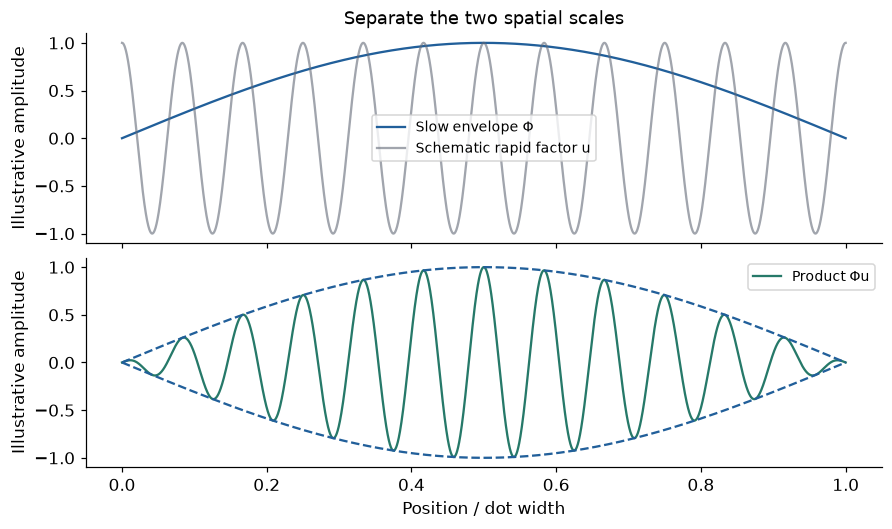

In [9]:
# @title Experiment 5 — distinguish a smooth envelope from lattice-scale variation {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
lattice_periods = 12 # @param {"type": "slider", "min": 6, "max": 24, "step": 1}

def envelope_plot(periods=12):
    x=np.linspace(0,1,3000)
    envelope=np.sin(np.pi*x)
    # Schematic real-valued lattice modulation, not a material Bloch-function calculation.
    lattice=np.cos(2*np.pi*periods*x)
    fig,ax=plt.subplots(2,1,figsize=(8,4.7),sharex=True,layout='constrained')
    ax[0].plot(x,envelope,color=BLUE,label='Slow envelope Φ')
    ax[0].plot(x,lattice,color=GRAY,alpha=.6,label='Schematic rapid factor u')
    ax[0].legend(fontsize=9)
    ax[0].set(ylabel='Illustrative amplitude',title='Separate the two spatial scales')
    ax[1].plot(x,envelope*lattice,color=GREEN,label='Product Φu')
    ax[1].plot(x,envelope,color=BLUE,ls='--')
    ax[1].plot(x,-envelope,color=BLUE,ls='--')
    ax[1].set(xlabel='Position / dot width',ylabel='Illustrative amplitude')
    ax[1].legend(fontsize=9)
    plt.show()
lab('envelope',envelope_plot,{'periods':W.IntSlider(description='Lattice periods',value=12,min=6,max=24,continuous_update=False)}, form_values={'periods': int(lattice_periods)})

## 5 · Creating an electron and a hole costs energy

Choose the bulk valence edge as zero on an **electron-energy diagram**.
The bulk conduction edge lies at $E_{g,0}$.
Confinement places the electron level above that edge by $E_e$ and the valence-electron level below its edge by $E_h$:
$$E_{\rm transition}^{(0)}=E_{g,0}+E_e+E_h.$$
Both confinement contributions are positive. Although the valence-electron level is drawn downward, creating its hole costs additional positive energy.

The electron and hole attract. This lowers the pair's energy relative to the noninteracting electron–hole pair:
$$E_{\rm pair}\approx E_{g,0}+E_e+E_h-E_{\rm attraction}.$$
Here $E_{\rm attraction}>0$ is the magnitude. The signed correction is negative.

In bulk, an **exciton** is an electron–hole pair bound by Coulomb attraction, with a characteristic extent called the exciton Bohr radius.
In strongly confined dots the boundary primarily sets the pair's extent; attraction perturbs its energy. The term exciton is still used for these pair excitations.

**Predict:** A hole level moves farther below the valence edge. Does creating the electron–hole pair cost more or less energy?

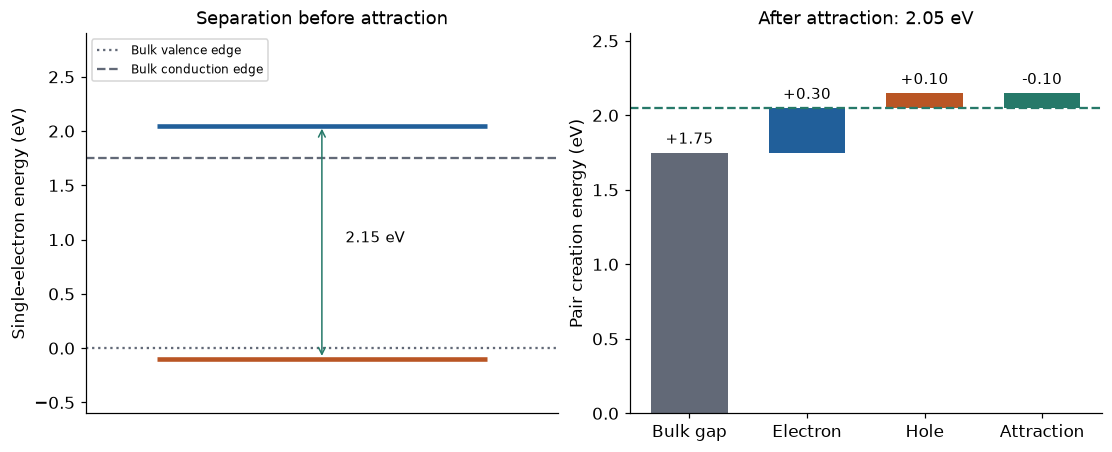

In [10]:
# @title Experiment 6 — read a band diagram without getting the hole sign wrong {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
electron_cost_eV = 0.3 # @param {"type": "slider", "min": 0.1, "max": 1.0, "step": 0.05}
hole_cost_eV = 0.1 # @param {"type": "slider", "min": 0.05, "max": 0.5, "step": 0.05}
attraction_magnitude_eV = 0.1 # @param {"type": "slider", "min": 0.0, "max": 0.2, "step": 0.02}

def pair_plot(ee=.3,eh=.1,attraction=.1):
    eg=1.75
    pair=eg+ee+eh-attraction
    fig,ax=plt.subplots(1,2,figsize=(10,4),layout='constrained')
    ax[0].axhline(0,color=GRAY,ls=':',label='Bulk valence edge')
    ax[0].axhline(eg,color=GRAY,ls='--',label='Bulk conduction edge')
    ax[0].hlines(-eh,.15,.85,color=ORANGE,lw=3)
    ax[0].hlines(eg+ee,.15,.85,color=BLUE,lw=3)
    ax[0].annotate('',xy=(.5,eg+ee),xytext=(.5,-eh),
                   arrowprops=dict(arrowstyle='<->',color=GREEN))
    ax[0].text(.55,(eg+ee-eh)/2,f'{eg+ee+eh:.2f} eV',fontsize=10)
    ax[0].set(xlim=(0,1),xticks=[],ylim=(-.6,2.9),
              ylabel='Single-electron energy (eV)',title='Separation before attraction')
    ax[0].legend(loc='upper left',fontsize=8)
    vals=[eg,ee,eh,-attraction]
    bottom=0.
    for i,(v,color) in enumerate(zip(vals,[GRAY,BLUE,ORANGE,GREEN])):
        ax[1].bar(i,v,bottom=bottom,color=color,width=.65)
        ax[1].text(i,bottom+max(v,0)+.06,f'{v:+.2f}',ha='center',fontsize=10)
        bottom+=v
    ax[1].axhline(pair,color=GREEN,ls='--')
    ax[1].set(xticks=range(4),xticklabels=['Bulk gap','Electron','Hole','Attraction'],
              ylim=(0,eg+ee+eh+.4),ylabel='Pair creation energy (eV)',
              title=f'After attraction: {pair:.2f} eV')
    plt.show()
lab('pair',pair_plot,{'ee':slider('Electron cost',.3,.1,1,.05),
                     'eh':slider('Hole cost',.1,.05,.5,.05),
                     'attraction':slider('Attraction (eV)',.1,0,.2,.02)}, form_values={'ee': electron_cost_eV, 'eh': hole_cost_eV, 'attraction': attraction_magnitude_eV})

The controls above are an **energy bookkeeping exercise**. In a physical model these contributions depend on radius, masses, and screening; we calculate that dependence in the next notebook.

This pair energy is an approximate band-edge excitation energy. It does not by itself predict an emission spectrum, a lifetime, or which transitions are allowed. Those require later parts of Section 2.

**My reasoning:** The hole contribution increases the excitation energy because ______. Attraction lowers it because ______.

In [11]:
# @title Checkpoint — separating the bulk gap from confinement {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
your_answer = "Choose an answer" # @param ["Choose an answer", "The entire optical transition energy.", "The confinement contribution, with fixed mass and state.", "The bulk semiconductor gap."]

quiz('scaling','If the dot radius halves, what quadruples in the simplest confinement model?',
     ['The entire optical transition energy.',
      'The confinement contribution, with fixed mass and state.',
      'The bulk semiconductor gap.'],1,
     ['The bulk gap stays fixed; attraction, if included, has a different scaling.',
      'Confinement is proportional to 1/R². Keep it separate from the fixed bulk gap and the 1/R attraction.',
      'The bulk gap is a material parameter in this model, not the dot confinement shift.'], form_answer=your_answer)

## 6 · Close the notebook and explain

Answer these in your own words before revealing the guide.

1. Derive the sine shape, the allowed wave numbers, and the normalization factor from their three requirements.
2. How can a wavefunction be negative while probabilities remain positive?
3. Why does the ground state of an infinite box have nonzero energy?
4. An electron has zero average directed momentum in the box. Why can its kinetic energy still be positive?
5. Why does a smaller effective mass give wider level spacings?
6. What is the difference between a hole, an electron, and an exciton?
7. Which part of the wavefunction responds to the dot boundary in the approximation used here?
8. If a photon energy changes from 2 to 2.5 eV, how does its wavelength change?
9. Why should you not read the band-edge excitation energy as the full emission prediction?

**My explanations:**

1.
2.
3.
4.
5.
6.
7.
8.
9.

<details><summary>Answer guide — compare reasoning, not wording</summary>
<ol>
<li>The Schrödinger equation admits sine and cosine solutions inside the box. The left wall removes cosine, the right wall requires k = nπ/a, and unit total probability sets the magnitude of the prefactor to √(2/a).</li>
<li>Probability comes from the squared magnitude; overall sign does not change it.</li>
<li>A constant nonzero wave cannot satisfy both zero boundary values. The n = 0 solution is identically zero and cannot represent a normalized particle.</li>
<li>Average momentum can cancel between opposite contributions, while average momentum squared remains positive. Kinetic energy depends on the latter.</li>
<li>At a fixed allowed wave number, kinetic energy is inversely proportional to effective mass.</li>
<li>An electron occupies a conduction state; a hole describes a missing valence electron; an exciton is an electron–hole pair excitation whose interaction matters.</li>
<li>The smooth envelope. The Bloch factor records the lattice-scale structure.</li>
<li>Approximately 620 nm becomes 496 nm: greater energy, shorter wavelength.</li>
<li>Relaxation, selection rules, fine structure, and other processes are absent from this energy-only model.</li>
</ol>
</details>

**Ready for §2.1?** You should be able to explain all nine without the guide, and redo the box scaling questions a day later.
If an explanation feels memorized, return to its experiment and change one parameter before predicting again.

## Next: use these ideas in a sphere

[Open 02 · Section 2.1 in Colab](https://colab.research.google.com/github/Shlok-Joseph-Paul/physical-modeling-intuition/blob/main/klimov_section2/02_spherical_quantum_box.ipynb)

**Source and scope.** Pietryga et al., *Spectroscopic and Device Aspects of Nanocrystal Quantum Dots*, Chemical Reviews 116, 10513–10622 (2016), [DOI: 10.1021/acs.chemrev.6b00169](https://doi.org/10.1021/acs.chemrev.6b00169). The foundations prepare for §2.1, journal pp. 10515–10517. The explanations and figures here are newly created; the source PDF is not redistributed.

Optional background if a concept remains unclear: [MIT OpenCourseWare, Quantum Physics I, video lectures](https://ocw.mit.edu/courses/8-04-quantum-physics-i-spring-2016/pages/video-lectures/), especially interpretation of the wavefunction and the infinite well. These are supplements, not prerequisites to finish this lesson.

Implementation references: [Jupyter Widgets](https://ipywidgets.readthedocs.io/en/stable/examples/Using%20Interact.html); physical constants are obtained from scipy.constants.